# Part 1: Mall Customer Segmentation using Clustering Models
This notebook covers data preprocessing, feature scaling, K-Means clustering (with Elbow method), Hierarchical clustering (with Dendrogram), and DBSCAN clustering.


In [ ]:

import pandas as pd
import numpy as np


df_mall = pd.read_csv('Mall_Customers.csv')

print("--- Dataset Shape ---")
print(df_mall.shape)

print("\n--- First 5 Rows ---")
display(df_mall.head())

print("\n--- Missing Values Check ---")
print(df_mall.isnull().sum())

print("\n--- Summary Statistics ---")
display(df_mall.describe())

--- Dataset Shape ---
(200, 5)

--- First 5 Rows ---


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



--- Missing Values Check ---
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

--- Summary Statistics ---


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Step 2: Feature Selection and Standardization


In [7]:

from sklearn.preprocessing import StandardScaler

# Hum sirf relevant numerical features select kar rahe hain clustering ke liye
X_features = df_mall[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print("Features successfully scaled!")
print("Scaled Data Shape:", X_scaled.shape)

Features successfully scaled!
Scaled Data Shape: (200, 3)


## Step 3: Finding Optimal K using the Elbow Method 

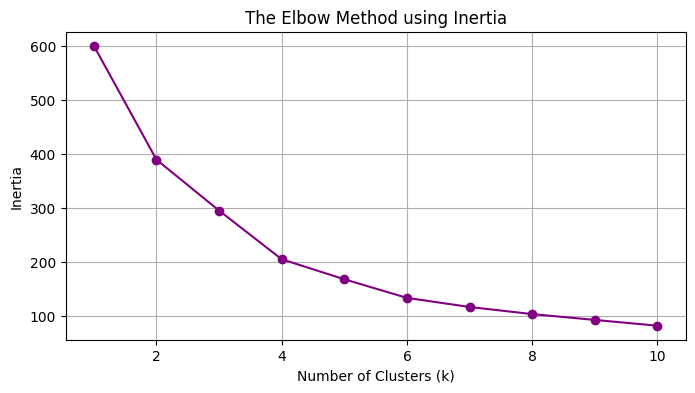

In [8]:
# Step 3: Fit K-Means for a range of k values (1-10) and plot the Elbow curve
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='purple', linestyle='-')
plt.title('The Elbow Method using Inertia')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

## Step 4: Final K-Means Model with Optimal k, Visualization, and Evaluation


Silhouette Score for K-Means (k=5): 0.4166


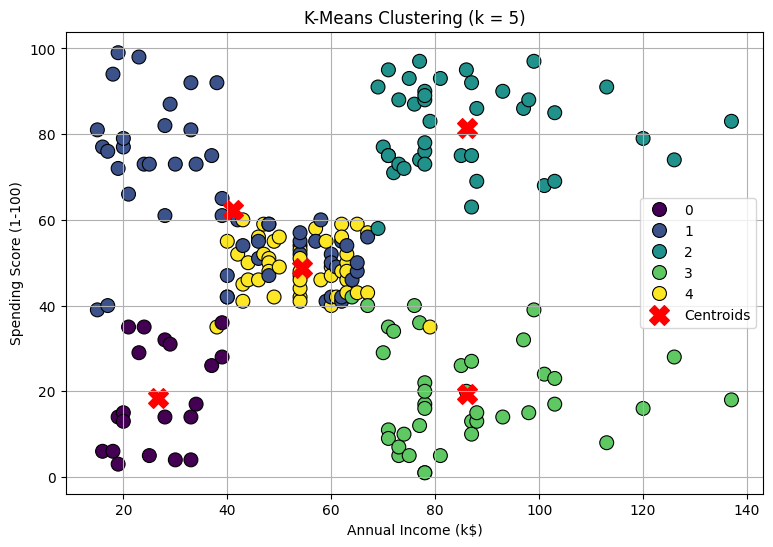

In [9]:
# Step 4: Fit K-Means with k=5, plot clusters, and calculate Silhouette Score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns


optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)


df_mall['Cluster'] = cluster_labels

# Silhouette Score calculate
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score for K-Means (k={optimal_k}): {sil_score:.4f}")

# 2D Scatter Plot (Annual Income vs Spending Score)
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster', 
    data=df_mall, 
    palette='viridis', 
    s=100, 
    edgecolor='black'
)

# Cluster centers  plot 
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 1], centers[:, 2], c='red', s=200, marker='X', label='Centroids')

plt.title(f'K-Means Clustering (k = {optimal_k})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

## Step 5: Hierarchical Clustering and Dendrogram

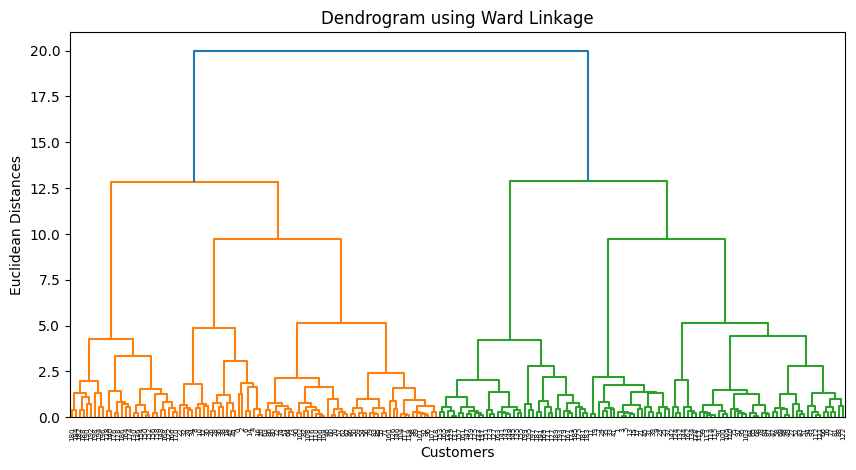

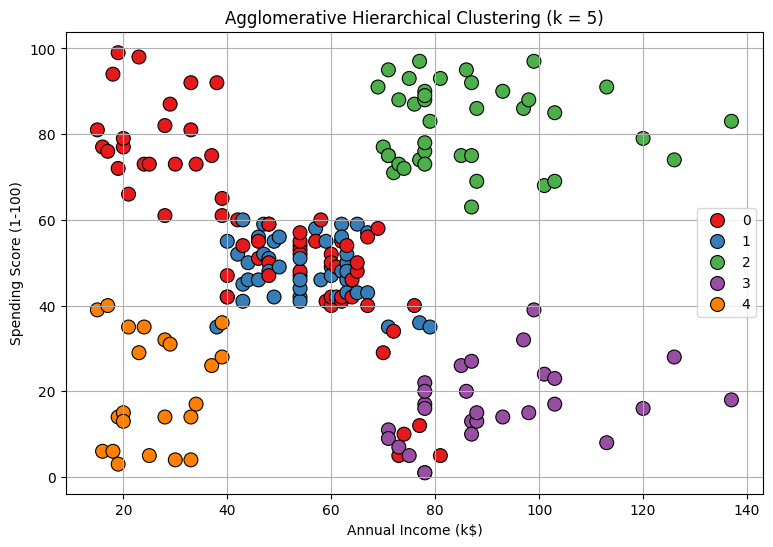

In [10]:
# Step 5: Plot dendrogram using Ward linkage and fit Agglomerative Clustering
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram using Ward Linkage')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.show()

# according to  Ward linkage  k = 5 is best , now  Agglomerative Clustering fit it
agg_cluster = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
df_mall['Agg_Cluster'] = agg_cluster.fit_predict(X_scaled)

# Hierarchical clusters & scatter plot
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Agg_Cluster', 
    data=df_mall, 
    palette='Set1', 
    s=100, 
    edgecolor='black'
)
plt.title('Agglomerative Hierarchical Clustering (k = 5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

## Step 6: DBSCAN Clustering and Noise Detection



Unique labels found by DBSCAN: [-1  0]
Number of noise points (-1): 6


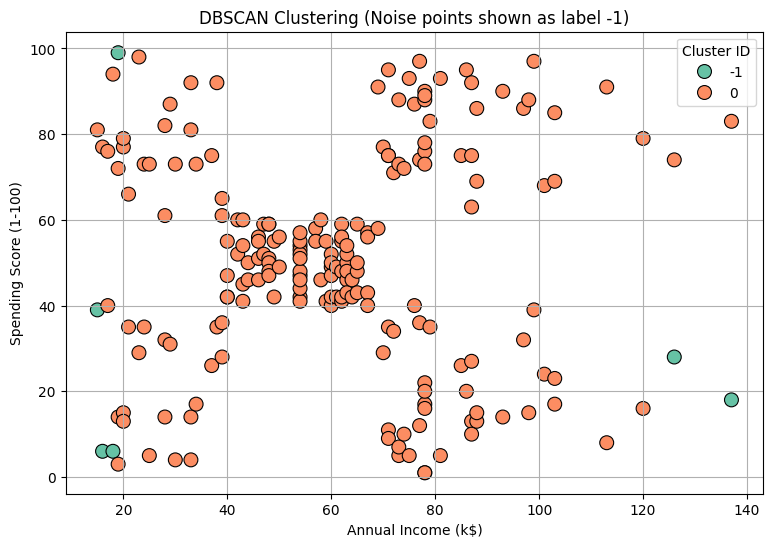

In [11]:
# Step 6: Fit DBSCAN and visualize clusters including noise points
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

# DBSCAN model fit it 
dbscan = DBSCAN(eps=0.8, min_samples=5)
df_mall['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)


print("Unique labels found by DBSCAN:", df_mall['DBSCAN_Cluster'].unique())
print("Number of noise points (-1):", (df_mall['DBSCAN_Cluster'] == -1).sum())


plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='DBSCAN_Cluster', 
    data=df_mall, 
    palette='Set2', 
    s=100, 
    edgecolor='black'
)
plt.title('DBSCAN Clustering (Noise points shown as label -1)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.show()

## Step 7: Comparison of Clustering Algorithms 

In [12]:

import pandas as pd

comparison_data = {
    "Algorithm": ["K-Means", "Hierarchical (Agglomerative)", "DBSCAN"],
    "Core Assumption": [
        "Assumes spherical, equally sized clusters", 
        "Assumes hierarchical tree structure (Ward linkage)", 
        "Assumes dense, arbitrarily shaped clusters"
    ],
    "Handling of Outliers/Noise": [
        "Sensitive to outliers (pulls centroids)", 
        "Can be sensitive to outliers depending on linkage", 
        "Explicitly detects noise and labels them as -1"
    ],
    "Pre-specify Clusters (k)?": [
        "Yes (requires k upfront)", 
        "Yes (requires number of clusters)", 
        "No (determines clusters based on density & eps)"
    ],
    "Scalability": [
        "High / Fast ($O(nKIt)$)", 
        "Low / Slow for large datasets ($O(n^3)$)", 
        "Medium (depends on spatial indexing)"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

,Algorithm,Core Assumption,Handling of Outliers/Noise,Pre-specify Clusters (k)?,Scalability
0,K-Means,"Assumes spherical, equally sized clusters",Sensitive to outliers (pulls centroids),Yes (requires k upfront),High / Fast ($O(nKIt)$)
1,Hierarchical (Agglomerative),Assumes hierarchical tree structure (Ward link...,Can be sensitive to outliers depending on linkage,Yes (requires number of clusters),Low / Slow for large datasets ($O(n^3)$)
2,DBSCAN,"Assumes dense, arbitrarily shaped clusters",Explicitly detects noise and labels them as -1,No (determines clusters based on density & eps),Medium (depends on spatial indexing)


## Step 8: Clustering Summary & Business Insights

### **Summary of Customer Segmentation Analysis**
Through this unsupervised learning workflow on the Mall Customer dataset, we successfully identified **5 meaningful customer segments** using K-Means and Hierarchical clustering algorithms, while DBSCAN effectively isolated noise points and extreme outliers. 

Among the models, **K-Means (with $k=5$) produced the most interpretable and distinct clusters**, which mapped exceptionally well to the multi-dimensional feature space of Age, Annual Income, and Spending Score. 

#### **Business Interpretation of Segments:**
1. **The Target Group (High Income, High Spending):** Premium customers who spend heavily and earn high salaries; they are prime targets for loyalty programs and luxury promotions.
2. **The Prudent Group (High Income, Low Spending):** Wealthy individuals who are careful with their money; they can be targeted with value-driven or investment offers to boost engagement.
3. **The Average Group (Medium Income, Medium Spending):** Standard middle-class shoppers who form the bulk of routine mall traffic.
4. **The Budget Group (Low Income, Low Spending):** Cost-conscious shoppers who prefer economical products and discounts.
5. **The Vulnerable/Impulsive Group (Low Income, High Spending):** Younger customers who spend beyond their means; they represent high-risk credit or impulse-buyer segments.

#### **Core Driving Hypothesis:**
The spending behavior of the highest-value segment (High Income, High Spending) is primarily driven by **lifestyle branding, status reinforcement, and experiential shopping**, rather than mere product utility. They value exclusivity, personalized customer service, and premium brand prestige, which justifies their high spending score despite high pricing.